In [1]:
from tensorflow import keras
import tensorflow as tf

from tensorflow.keras import models, layers #type: ignore
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

from tqdm import tqdm
import matplotlib.pyplot as plt 
import numpy as np 

import sys
sys.path.append('..')  # Add parent directory to path


from utils.data_loading import load_dataset


In [31]:
x, y = load_dataset('../input', file_pattern='data_{}.npy', n_files=1000)


norm = y.max()
# Normalização
y /= y.max()


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.25)

Loading data: 100%|██████████| 1000/1000 [00:07<00:00, 129.37it/s]


In [32]:
early_stopping = keras.callbacks.EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',   
    patience=5,          
    verbose=1,          
    factor=0.75,          
    min_lr=0.0000001       
)

learning_rate_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,  # Initial learning rate for training
    decay_steps=100,            # Number of steps before decaying the learning rate
    decay_rate=0.5,              # Rate at which the learning rate decreases
)

lr_callback = keras.callbacks.LearningRateScheduler(learning_rate_schedule)


In [33]:
# defining the model

model = models.Sequential()

model.add(layers.Flatten())


model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(.01))
model.add(layers.Dense(16, activation='relu'))

model.add(layers.Dense(1))

model.compile(loss=keras.losses.MeanSquaredError(), optimizer='nadam', metrics=keras.metrics.MeanAbsoluteError())


history = model.fit(x_train, y_train, validation_split=.2, epochs=100, batch_size=8, verbose=1, callbacks=[reduce_lr])

Epoch 1/100
75/75 [==============================] - 1s 6ms/step - loss: 37.3024 - mean_absolute_error: 2.0985 - val_loss: 0.0832 - val_mean_absolute_error: 0.2477 - lr: 0.0010
Epoch 2/100
75/75 [==============================] - 0s 5ms/step - loss: 5.8818 - mean_absolute_error: 0.8178 - val_loss: 0.0878 - val_mean_absolute_error: 0.2567 - lr: 0.0010
Epoch 3/100
75/75 [==============================] - 0s 5ms/step - loss: 2.7303 - mean_absolute_error: 0.6847 - val_loss: 0.4117 - val_mean_absolute_error: 0.5674 - lr: 0.0010
Epoch 4/100
75/75 [==============================] - 0s 5ms/step - loss: 1.7781 - mean_absolute_error: 0.5986 - val_loss: 0.7178 - val_mean_absolute_error: 0.7919 - lr: 0.0010
Epoch 5/100
75/75 [==============================] - 0s 5ms/step - loss: 0.8783 - mean_absolute_error: 0.5110 - val_loss: 0.1865 - val_mean_absolute_error: 0.3574 - lr: 0.0010
Epoch 6/100
75/75 [==============================] - 0s 5ms/step - loss: 0.4711 - mean_absolute_error: 0.4140 - val_los

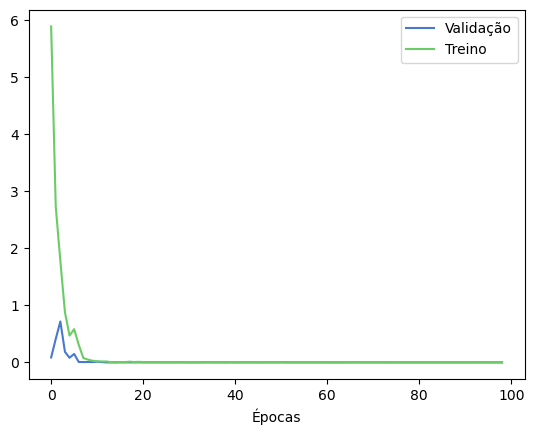

In [34]:
plt.plot(history.history['val_loss'][1:], label='Validação')
plt.plot(history.history['loss'][1:], label='Treino')


plt.xlabel('Épocas')
plt.legend()


# plt.savefig("imagens/loss_h0_dense")

plt.show()

In [35]:
y_pred = model.predict(x_test)


r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

mse

8/8 [==============================] - 0s 2ms/step


0.0008586452023289612

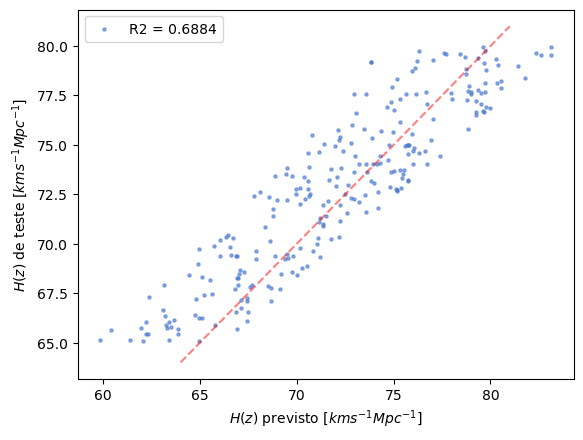

In [36]:


plt.style.use('seaborn-v0_8-muted')

linha = np.linspace(64, 81)
# linha = np.linspace(.28, .35, 2500)


plt.scatter(y_pred*norm, y_test*norm, s=5, alpha=.6, label=f'R2 = {r2:.4f}')
plt.plot(linha, linha, alpha=.5, c='red', ls='--')

plt.legend()


plt.xlabel(r'$H (z)$ previsto [$km s^{-1} Mpc^{-1}$] ')
plt.ylabel(r'$H (z)$ de teste [$km s^{-1} Mpc^{-1}$] ')


# plt.savefig("imagens/metrics_h0_dense")
plt.show()




In [40]:
# forecasting "real" H(0)

real = np.load('../input/data_real80.npy')
real = real[real[:, 1].argsort()]

real = real.reshape(-1,80,2)

In [41]:
real[:, :, 0][0]

array([0.1       , 0.11772152, 0.13544304, 0.15316456, 0.17088608,
       0.18860759, 0.20632911, 0.22405063, 0.24177215, 0.25949367,
       0.27721519, 0.29493671, 0.31265823, 0.33037975, 0.34810127,
       0.36582278, 0.3835443 , 0.40126582, 0.41898734, 0.43670886,
       0.45443038, 0.4721519 , 0.48987342, 0.50759494, 0.52531646,
       0.54303797, 0.56075949, 0.57848101, 0.59620253, 0.61392405,
       0.63164557, 0.64936709, 0.66708861, 0.68481013, 0.70253165,
       0.72025316, 0.73797468, 0.7556962 , 0.77341772, 0.79113924,
       0.80886076, 0.82658228, 0.8443038 , 0.86202532, 0.87974684,
       0.89746835, 0.91518987, 0.93291139, 0.95063291, 0.96835443,
       0.98607595, 1.00379747, 1.02151899, 1.03924051, 1.05696203,
       1.07468354, 1.09240506, 1.11012658, 1.1278481 , 1.14556962,
       1.16329114, 1.18101266, 1.19873418, 1.2164557 , 1.23417722,
       1.25189873, 1.26962025, 1.28734177, 1.30506329, 1.32278481,
       1.34050633, 1.35822785, 1.37594937, 1.39367089, 1.41139

In [42]:

final_real = model.predict(real, verbose=0)

In [44]:
final_real*norm

array([[67.07205]], dtype=float32)

In [45]:
def mc_dropout_predict(model, X, n_iter=10000):
    """
    X shape: (batch_size, 80, 2) ou (batch_size, 160) se flatten
    """
    predictions = []
    for _ in range(n_iter):
        # Ativar dropout durante inferência
        pred = model(X, training=True).numpy()
        predictions.append(pred)
    
    predictions = np.array(predictions)
    mean = predictions.mean(axis=0)
    std = predictions.std(axis=0)
    
    return mean, std

# Exemplo para uma amostra
X_sample = real  # shape: (1, 80, 2)
mean, std = mc_dropout_predict(model, X_sample)
print(f"{mean[0][0]:.2f} ± {1.96*std[0][0]:.2f}")

0.84 ± 0.07


In [46]:
print(f"{mean[0][0]*norm:.2f} ± {1.96*std[0][0]*norm:.2f}")

67.42 ± 5.46
